# Primeiro trabalho prático

## Parte teórica (4 pontos cada)

Classifique as afirmações em Verdadeiro ou Falso, justifique as afirmativas falsas

1 - As imagens matricias são mais usadas em logos, pois não apresentam serrilhamento quando são ampliadas

In [42]:
False

False

Justificativa: Esta afirmativa é falsa porque o serrilhamento é um dos problemas encontrados quando uma imagem matricial é ampliada. Diferentemente das imagens vetoriais que são estruturadas por equações matemáticas, as imagens matriciais são estruturas em grades de pixels. Como elas são formadas dessa forma, o software tem a necessidade de "esticar" os pontos ou inventar novos pixels para preencher os espaços, causando serrilhamento.

2 - Códigos feitos a mão e no Numpy levam o mesmo tempo para rodar, usamos o Numpy apenas por convêniencia

In [43]:
False

False

Justificativa: Esta afirmativa é falsa porque o custo computacional dos dois métodos é discrepante. O NumPy é uma biblioteca/ferramenta que além de facilitar diversas implementações que levariam diversas linhas em python puro para serem desenvolvidas, é otimizado em diversos sentidos, como os arrays. Manipulações de arrays e imagens que levariam tempo e custo para serem implementadas, são rapidamente contornadas por uma forma mais simples, intuitiva e prática usando funções do NumPy.

3 - Um dos usos do histograma é realizar conversões entre os espaços de cores

In [44]:
False

False

Justificativa: Esta afirmativa é falsa porque conversões entre os espaços de cores são feitas mediante fórmulas de manipulação de cores dependendo do tipo do modelo (Aditivo ou Subtrativo). O Histograma é mais utilizado para analisar e manipular a distribuição de intensidade dentro de um espaço de cor já existente. Além disso, ele pode ser utilizado para análise de contraste e equalização de imagens.

4 - O código abaixo é usado para importar uma imagem e retirar o terceiro campo de cor (Blue, ou azul, do RGB)

```imagem = np.array(Image.open('Clara.png'))[:, :, :3]```

In [45]:
False

False

Justificativa: Esta afirmativa é falsa poruqe esse código não retira o terceiro campo de cor (Blue do RGB) e sim o canal Alpha (transparência do RGBA). O ':3' determina a escolha dos 3 canais principais (RGB) e a exclusão do próximo canal.

5 - Utilizamos técnicas como HDR para melhorar a iluminação de imagens

In [46]:
True

True

6 - O espaço de cores RGB é amplamente utilizado pois é o mais intuitivo para seres humanos

In [47]:
False

False

Justificativa: Esta justificativa é falsa porque o espaço de cores RGB realmente é o mais utilizado, mas não é o mais intuitivo para seres humanos. O espaço de cores mais intuitivo é o HSV em que cores podem ser facilmente adaptadas modificando apenas um dos 3 componentes (Hue, Saturation ou Value), o que difere do RGB - cores nesse espaço geralmente necessitam de modificações nos 3 componentes ao mesmo tempo.

7 - Imagens vetoriais apresentam serrilhamento quando são ampliadas

In [48]:
False

False

Justificativa: Esta afirmação é falsa porque imagens vetoriais não apresentam serrilhamento, uma vez que são compostas por formas geométricas definidas por equações matemáticas, permitindo que sejam redimensionadas sem perda de qualidade. 

8 -  A lógica XOR aplicada em uma imagem detecta os pixels que mudaram de valor

In [49]:
True

True

9 -  A lógica XOR aplicada em uma imagem detecta os pixels que mudaram de valor

In [50]:
True

True

10 - Bordas são mudanças drásticas de iluminação na imagem

In [51]:
True

True

# Parte prática (5 pontos cada, exceto a questão 11 que vale 10)

## Material de apoio

### Importações

```python
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
```

### Manipulação de imagens

```python
img = Image.open('nome.extensão')
img = np.array(Image.open('nome.extensão'))
img = img[:, :, :3]
img_pil = Image.fromarray(img_np)
img.save('nome.png')
Image.fromarray(img).save('nome_arquivo.extensao')
(l,c,p) = img.shape
```

### Greyscale

#### Algoritmo genérico, substituir o método escolhido
```python
img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        r = float(img_np[i, j, 0])
        g = float(img_np[i, j, 1])
        b = float(img_np[i, j, 2])
        
        img_avg[i, j] = (aplicar método)
```

#### Métodos: 


Lightness: $\frac{max(R,G,B)+min(R,G,B)}{2}$


Average: $\frac{R+G+B}{3}$


Luminosity: $0.2126 \cdot R + 0.7152 \cdot G + 0.0722 \cdot B$


RGB para CMY:
### <font color="red">R</font><font color="green">G</font><font color="blue">B</font> para <font color="cyan">C</font><font color="magenta">M</font><font color="yellow">Y</font>
$$\begin{pmatrix}
    C \\ M \\ Y
\end{pmatrix} = \begin{pmatrix}
    1 \\ 1 \\ 1
\end{pmatrix} - \begin{pmatrix}
    R \\ G \\ B
\end{pmatrix} e \begin{pmatrix}
    R \\ G \\ B
\end{pmatrix} = \begin{pmatrix}
    1 \\ 1 \\ 1
\end{pmatrix} - \begin{pmatrix}
    C \\ M \\ Y
\end{pmatrix}$$
* **<font color="red">R</font>** + **<font color="cyan">C</font>** = 1 (ou 255);
* **<font color="green">G</font>** + **<font color="magenta">M</font>** = 1;
* **<font color="blue">B</font>** + **<font color="yellow">Y</font>** = 1.


Interpolação Bilinear:
Seja $I$ a imagem de entrada $L_{entrada}×C_{entrada}$ e $J$ a imagem de saída $L_{saída}×C_{saída}.$

Seja $s_L = L_{entrada}/L_{saída}$ e $s_C = C_{entrada}/C_{saída}.$

Seja $l_f = l \cdot s_L$ para $r=0,\ldots,R_{saída}-1$ e $c_f = c \cdot s_C$ para $c=0,\ldots,C_{saída}-1.$

Seja $r_0 = \lfloor{l_f}\rfloor$ e $c=\lfloor{c_f}\rfloor.$

Seja $\Delta_l = l_f - l_0$ e $\Delta_c = c_f - c_0.$

Então $J(l, c)$
$$=I(l_0, c_0) \cdot (1-\Delta_l) \cdot (1-\Delta_c)$$
$$+I(l_0+1, c_0) \cdot \Delta_l \cdot (1-\Delta_c)$$
$$+I(l_0, c_0+1) \cdot (1-\Delta_l) \cdot \Delta_c$$
$$+I(l_0+1, c_0+1) \cdot \Delta_l \cdot \Delta_c.$$

### Escalonamento com nearest neighbor

```python

(dx, dy) = (50, 40)
mario_tr = np.zeros(shape=(l + dy, c + dx, p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = j + dx
        new_y = i + dy
        mario_tr[new_y, new_x] = mario[i, j]

ls, cs = l * sy, c * sx
mario_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

for i in range(ls):
    for j in range(cs):
        new_y = int(np.floor(i * (l / ls)))
        new_x = int(np.floor(j * (c / cs)))
        
        mario_nn[i, j] = mario[new_y, new_x]
```
### Escalonamento clássico
```python
scale_x, scale_y = 2, 2
mario_scale = np.zeros(shape=(l * scale_y, c * scale_x, p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = np.round(j * scale_x)
        new_y = np.round(i * scale_y)
        mario_scale[new_y, new_x] = mario[i, j]

plt.imshow(mario_scale)
Image.fromarray(mario_scale).save('mario_scale.png')
```

### Cisalhamento

```python

alpha = np.pi / 6 # 30°

ls, cs = int(l * np.sqrt(2)), int(c * np.sqrt(2))
mario_rot = np.zeros((ls, cs, p), dtype=np.uint8)
for i in range(ls):
    for j in range(cs):
        cx = j - (ls / 2)
        cy = i - (cs / 2)
        
        new_x = int( cx * np.cos(alpha) + cy * np.sin(alpha) + l / 2)
        new_y = int(-cx * np.sin(alpha) + cy * np.cos(alpha) + c / 2)
        
        # Pegar apenas a imagem do Mario na original.
        if 0 <= new_x < c and 0 <= new_y < l:
            mario_rot[i, j] = mario[new_y, new_x]

plt.figure(figsize=(8, 8))
plt.imshow(mario_rot)

img_shear = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx)), p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = int(j + cx * i)
        new_y = int(cy * j + i)
        
        img_shear[new_y, new_x] = img[i, j]
```

### Imagem grayscale para imagem binária de 3 canais

```python
bin = np.zeros(shape=(l,c,3),dtype=np.uint8)
    
for i in range(l):
    for j in range(c):
        if img[i,j] > thresh: 
            bin[i,j,:] = 255 
        else: 
            bin[i,j,:] = 0

```
### Blending com escala genérica

```python
imagem_blending = (C * img_1) + ((1 - C) * img_2)
imagem_blending = imagem_blending.astype(np.uint8)
```

### Histograma
```python
def histogram_gray(img):
    (l, c) = img.shape
    histogram = np.zeros(256, dtype=np.int32)

    for i in range(l):
        for j in range(c):
            intensity = img[i, j]
            histogram[intensity] += 1
            
    return histogram

def show_histogram_gray(img):
    histogram = histogram_gray(img)
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram)

def show_histogram(img):
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])
    
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram_r, color='red')
    plt.bar(range(256), histogram_g, color='green')
    plt.bar(range(256), histogram_b, color='blue')

```
### Espelhamento
```python
refl = np.zeros(shape=example.shape, dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = -j
        new_y = i
        refl[new_y, new_x] = example[i, j]

plt.imshow(refl)
```


No outro eixo

```python
refl = np.zeros(shape=example.shape, dtype=np.uint8)
refl[::-1, ::1] = example
plt.imshow(refl)
```

### Detecção de bordas 
```python
Bordas são mudanças drásticas de iluminação na imagem
abs_tg_c = np.abs(np.diff(museum.astype(np.float64), axis=0, append=255))

abs_tg_l = np.abs(np.diff(museum.astype(np.float64), axis=1, append=255))

abs_tg = np.sqrt(abs_tg_c ** 2 + abs_tg_l ** 2)

threshold = 16
museum_border = np.zeros(shape=(l, c), dtype=np.uint8)
museum_border[abs_tg > threshold] = 255
```

### Operações lógicas
NOT:
```python
Inversão
bin1_not = np.bitwise_not(bin1)
bin2_not = np.invert(bin2)
```
AND:
```python
Comum entre duas imagens ou recorte
bin_and = np.bitwise_and(bin1, bin2)
```
OR: 
```python
União de duas imagens
bin_or = np.bitwise_or(bin1, bin2)
```
XOR 
```python
Detecção de mudança nas imagens
bin_xor = np.bitwise_xor(bin1, bin2)

Soma:
Redução de ruídos (média aritmética das imagens), HDRI (média também (usar float64)) e blending
Para evitar valores acima de 255, podemos dividir a soma por 2 (usando float64)

Subtração:
Detecção de movimentos, controle de qualidade e realce.
mvt = car2.astype(np.int16) - car1.astype(np.int16)
mvt = np.clip(mvt, 0, 255).astype(np.uint8)

Produto:
Sobrepor imagens, destacar cores ou efeito de fluorescência, podemos ter overflow ou underflow.
sobreposta = (metal_1.astype(np.float64) / 255) * (metal_2.astype(np.float64) / 255)
grayscale = np.average(metal_1, axis=2)
tinted = np.zeros(shape=metal_1.shape, dtype=np.uint8)

# laranja em RGB: (255, 127, 0)
# escala vermelho em 255 / 255 = 1
tinted[:, :, 0] = grayscale * (255 / 255)
# escala verde em 127 / 255 ~= 0.5
tinted[:, :, 1] = grayscale * (127 / 255)
# escala azul em 0 / 255 = 0
tinted[:, :, 2] = grayscale * (  0 / 255)
Tintura:
photo = np.array(Image.open('photo.jpg'))

plt.figure(figsize=(16, 16))
plt.subplot(2, 2, 1)
photo_mul = np.clip(photo * 1.5, 0, 255).astype(np.uint8)
plt.imshow(photo_mul)

plt.subplot(2, 2, 2)
photo_div = (photo / 1.5).astype(np.uint8)
plt.imshow(photo_div)

plt.subplot(2, 2, 3)
plt.imshow(photo)
```

**1 -** Importe as bibliotecas que serão usadas

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

**2 -** Abra as imagens techno.jpg, Shrine.jpg e Ninja.jpg, retire o canal alpha se necessário, exiba essas imagens e mostre o formato de cada uma

Techno shape: (500, 500, 3)
Shrine shape: (500, 500, 3)
Ninja shape: (250, 250, 3)


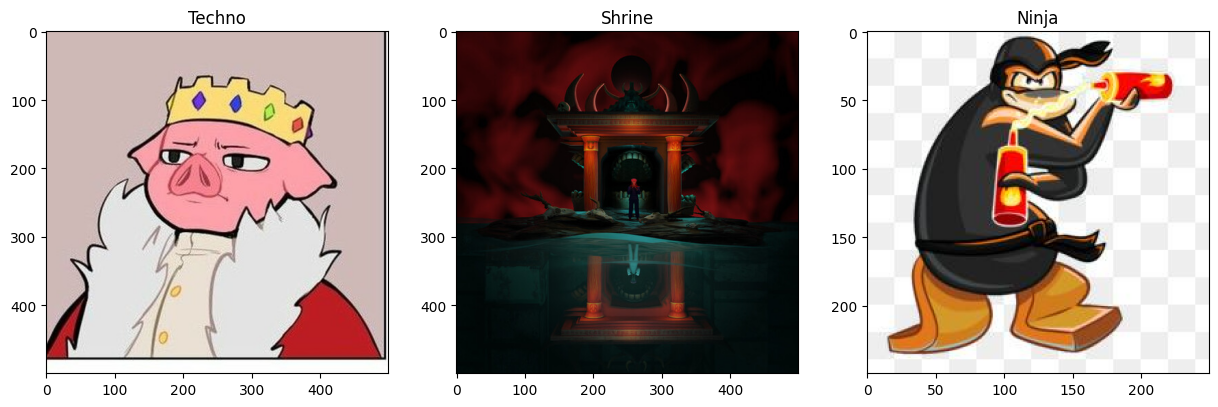

In [53]:
# Abrindo as imagens
techno = Image.open('techno.jpg')
shrine = Image.open('shrine.jpg')
ninja = Image.open('ninja.jpg')

# Retirada do canal alpha
np_techno = np.array(techno)
np_shrine = np.array(shrine)
np_ninja = np.array(ninja)

np_techno = np_techno[:,:, :3]
np_shrine = np_shrine[:,:, :3]
np_ninja = np_ninja[:,:, :3]

img_techno = Image.fromarray(np_techno)
img_shrine = Image.fromarray(np_shrine)
img_ninja = Image.fromarray(np_ninja)

# Exibindo as imagens + shapes de cada
fig, ax = plt.subplots (1, 3, figsize=(15, 5))

ax[0].imshow(img_techno)
ax[0].set_title("Techno")
print("Techno shape:", np_techno.shape)
ax[1].imshow(img_shrine)
ax[1].set_title("Shrine")
print("Shrine shape:", np_shrine.shape)
ax[2].imshow(img_ninja)
ax[2].set_title("Ninja")
print("Ninja shape:", np_ninja.shape)

**3 -** Crie uma função que realize o escalonamento de uma imagem para que Ninja e Techno fiquem do mesmo tamanho. Utilize o método de sua preferência e mostre o resultado

Text(0.5, 1.0, 'Ninja escalonado')

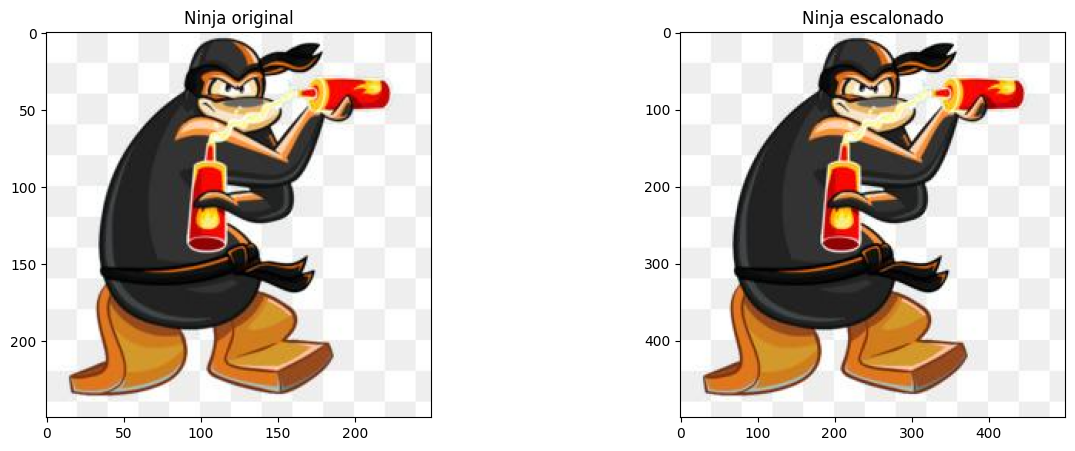

In [54]:
def escalonamento(img, largura, comprimento):
    ls = largura
    cs = comprimento

    image_zeros = np.zeros(shape=(ls, cs, img.shape[2]), dtype=np.uint8)

    for i in range(ls):
        for j in range(cs):
            new_y = int(np.floor(i * (img.shape[0] / ls)))
            new_x = int(np.floor(j * (img.shape[1] / cs)))

            image_zeros[i, j] = img[new_y, new_x]
    return image_zeros

# Chamada da função de escalonamento (ninja.shape -> techno.shape)
np_techno_l = np_techno.shape[0]
np_techno_c = np_techno.shape[1]
nova_img_ninja = escalonamento(np_ninja, np_techno_l, np_techno_c)

fig, ax = plt.subplots (1, 2, figsize=(15, 5))
ax[0].imshow(img_ninja)
ax[0].set_title("Ninja original")
ax[1].imshow(nova_img_ninja)
ax[1].set_title("Ninja escalonado")

**4 -** Apresente o Histograma da imagem Shrine. Mostre o resultado

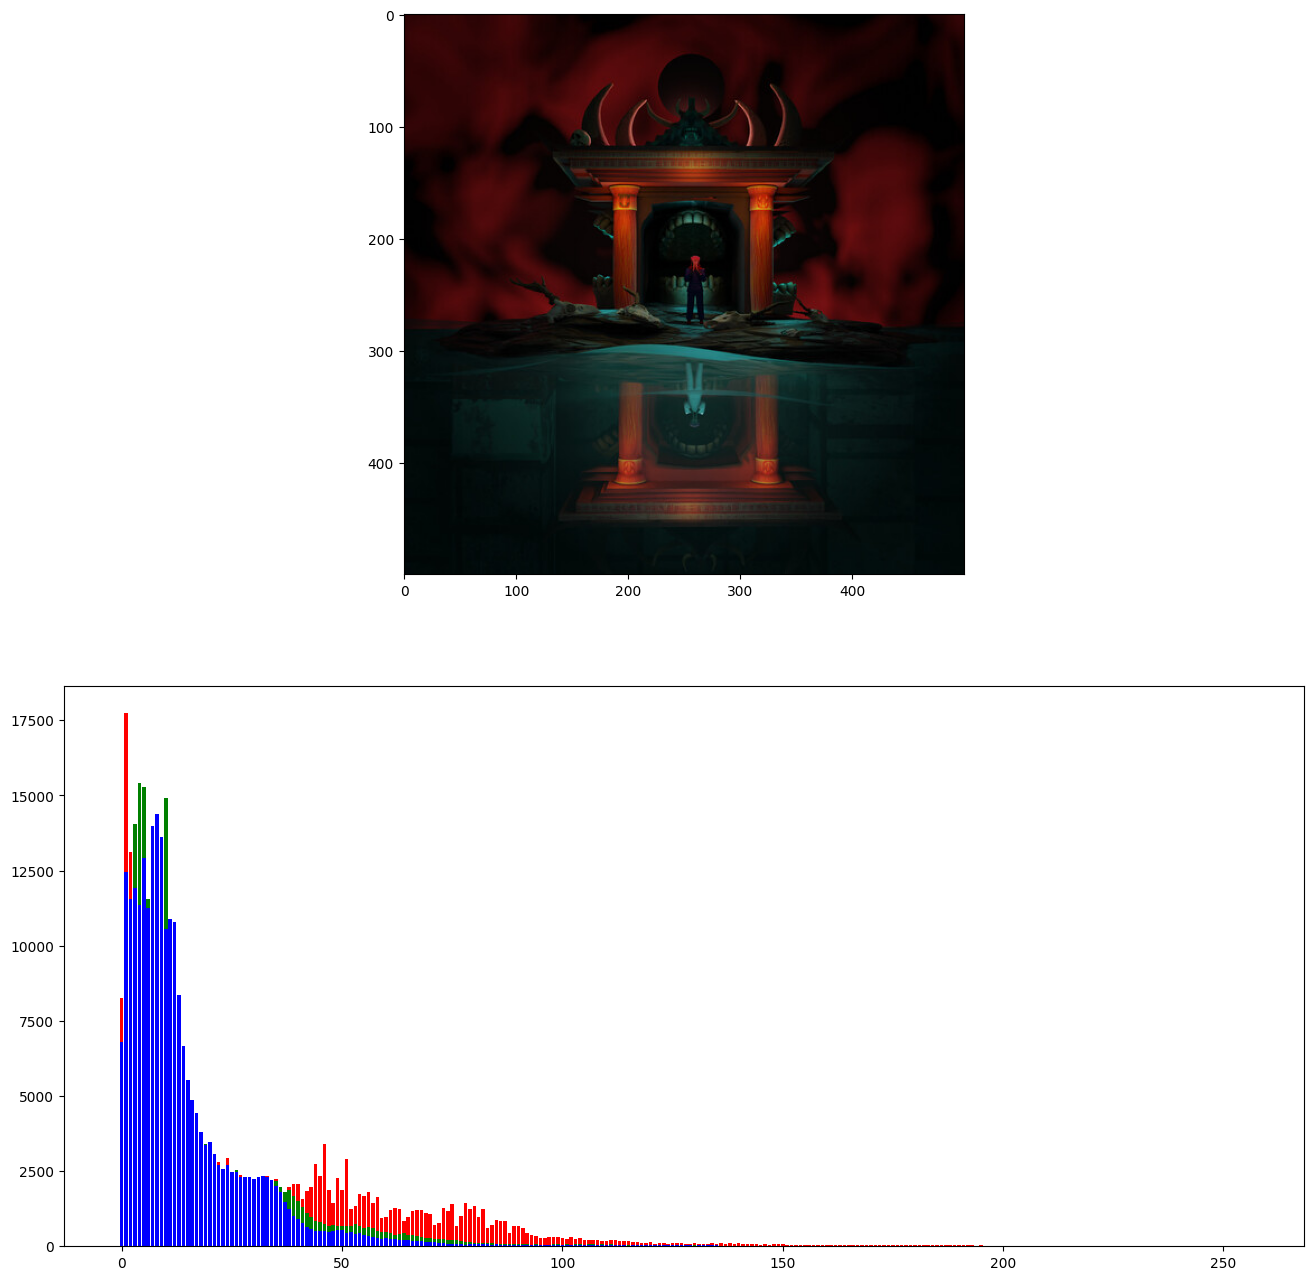

In [55]:
def histogram_gray(img):
    (l, c) = img.shape
    histogram = np.zeros(256, dtype=np.int32)

    for i in range(l):
        for j in range(c):
            intensity = img[i, j]
            histogram[intensity] += 1
            
    return histogram

def show_histogram(img):
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])
    
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram_r, color='red')
    plt.bar(range(256), histogram_g, color='green')
    plt.bar(range(256), histogram_b, color='blue')

show_histogram(np_shrine)

**5 -** Aplique o espelhamento no eixo X à imagem techno. Mostre o resultado

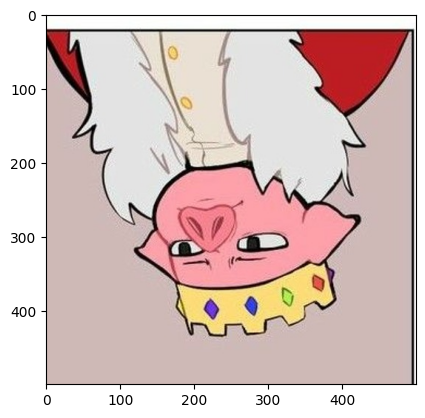

In [56]:
refl = np.zeros(shape=np_techno.shape, dtype=np.uint8)
for i in range(np_techno.shape[0]):
    for j in range(np_techno.shape[1]):
        new_x = j
        new_y = -i
        refl[new_y, new_x] = np_techno[i, j]

plt.imshow(refl)

**6 -** Realize a operação lógica *blending* entre a imagem gerada na Questão 3 e gerada na Questão 5, com o grau de influência de 50% em ambas. Mostre o resultado

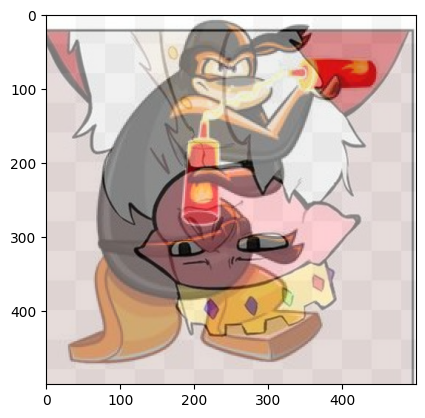

In [57]:
C = 0.5
imagem_blending = (C * nova_img_ninja) + ((1 - C) * refl)
imagem_blending = imagem_blending.astype(np.uint8)
plt.imshow(imagem_blending)

**7 -** Depois, aplique a operação NOT na imagem Shrine. Mostre o resultado

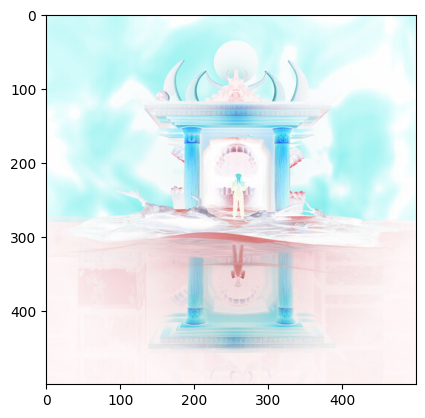

In [58]:
shrine_not = np.bitwise_not(np_shrine)
plt.imshow(shrine_not)

**8 -** Crie uma função para transformar imagem RGB em CMY

In [59]:
def rgb_para_cmy(img_rgb):
    
    img_cmy = (255 - img_rgb)

    return img_cmy

**9 -** Aplique a imagem da **questão 6 à função feita na questão 8**. Mostre o resultado

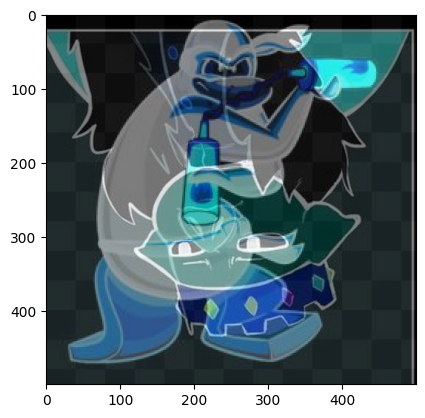

In [60]:
imagem_blending = rgb_para_cmy(imagem_blending)
plt.imshow(imagem_blending)

**10 -** Aplique a operação OR com a imagem resultante da questão 9 e questão 7, após isso salve a imagem  no disco com o nome "resultado1.jpg"

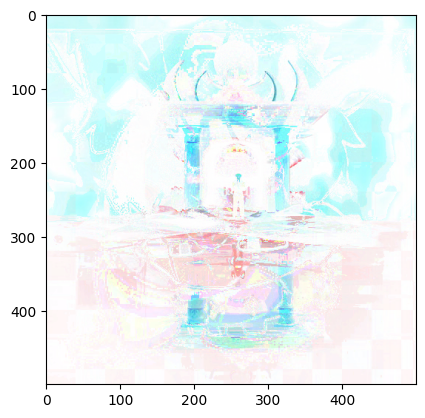

In [61]:
q10 = np.bitwise_or(imagem_blending, shrine_not)
plt.imshow(q10)
Image.fromarray(q10).save("resultado1.jpg")

**11 -** Aplique detecção de bordas usando NumPy com a imagem resultante da questão 10, após isso salve a imagem no disco com o nome "resultado2.jpg"

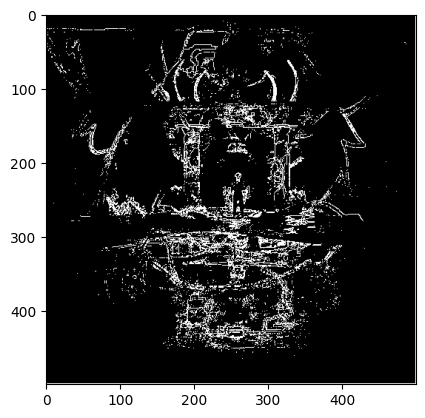

In [62]:
# Grayscale:

"""
q10_gray = np.zeros(shape=(l, c), dtype=np.float64)
for i in range(l):
    for j in range(c):
        q10_gray[i, j] = 0.2126*q10[i,j,0] + 0.7152*q10[i,j,1] + 0.0722*q10[i,j,2]

ou q10_gray = np.mean(q10, axis=2)

"""

# Preto e Branco:

"""
limiar = 128

for i in range(l):
    for j in range(c):

        r = float(imgnp[i, j, 0])
        g = float(imgnp[i, j, 1])
        b = float(imgnp[i, j, 2])
        
        img_avg[i,j] = (r + g + b) / 3
    
        if img_avg[i,j] > limiar:
            img_avg[i,j] = 255
        else:
            img_avg[i,j] = 0
            

plt.imshow(img_avg, cmap='gray')

ou 

def threshold(img, thresh):
    out = img.copy()
    out[img >  thresh] = 255
    out[img <= thresh] = 0
    return out
"""

l, c = q10.shape[0], q10.shape[1]

q10_gray = np.mean(q10, axis=2)

abs_tg_c = np.abs(np.diff(q10_gray, axis=0, append=0))
abs_tg_l = np.abs(np.diff(q10_gray, axis=1, append=0))

abs_tg = np.sqrt(abs_tg_c ** 2 + abs_tg_l ** 2)

threshold_borda = 16
q10_border = np.zeros(shape=(l, c), dtype=np.uint8)
q10_border[abs_tg > threshold_borda] = 255

plt.imshow(q10_border, cmap='gray')
Image.fromarray(q10_border).save("resultado2.jpg")

# Lembre de entregar tudo como um arquivo ZIP, com o arquivo resultado e seu notebook, NOMEADO COMO: "C09 - LX - SEU NOME COMPLETO"